Mounted at /content/drive
Unzipping /content/drive/MyDrive/all_shen_roi_ts.zip...
Loading MOVIE1 data...
Found 184 MOVIE1 files. Processing...
Final dataset: 184 subjects | condition: MOVIE1
Edge feature matrix: (184, 35778)

Running nested 5-fold CV...
  Outer fold 1: best_p=0.01 (inner Spearman r=0.220)
  Outer fold 2: best_p=0.01 (inner Spearman r=0.246)
  Outer fold 3: best_p=0.01 (inner Spearman r=0.288)
  Outer fold 4: best_p=0.1 (inner Spearman r=0.219)
  Outer fold 5: best_p=0.05 (inner Spearman r=0.270)

Permutation test: fixing p=0.01 (modal choice across outer folds: [0.01, 0.01, 0.01, 0.1, 0.05])
  permutations: 100/1000
  permutations: 200/1000
  permutations: 300/1000
  permutations: 400/1000
  permutations: 500/1000
  permutations: 600/1000
  permutations: 700/1000
  permutations: 800/1000
  permutations: 900/1000
  permutations: 1000/1000

NESTED 5-FOLD CV  (honest accuracy estimate)
Spearman r : 0.3040
R^2        : 0.0009
RMSE       : 13.6315
MAE        : 10.5601

PERM

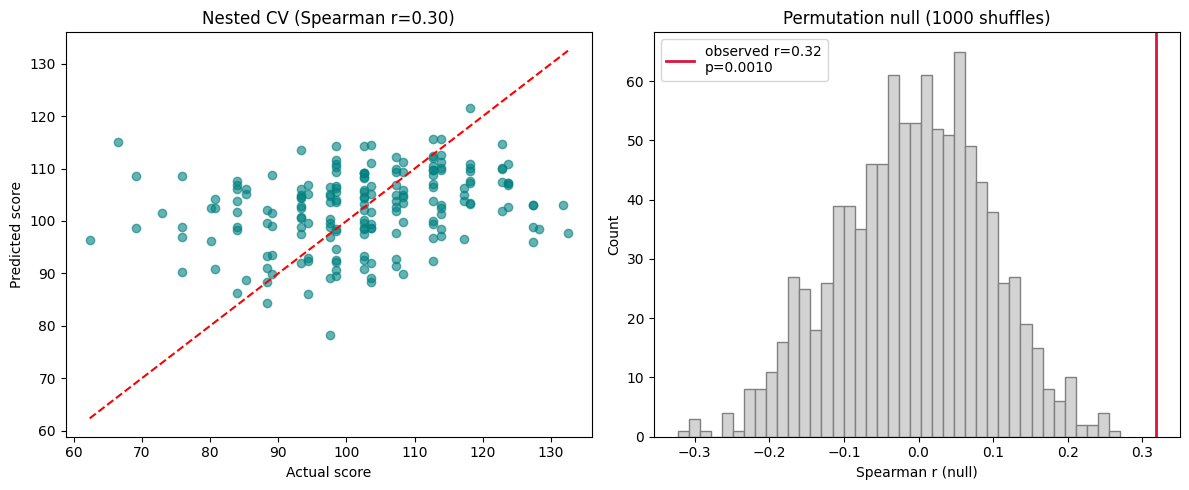

In [ ]:
"""
CPM baseline following Finn & Bandettini (2020), "Movie-watching outperforms
rest for functional connectivity-based prediction of behavior".

Differences from the paper (deliberate, for this baseline):
  - Predicts a single raw HCP measure (PicSeq_Unadj) instead of a PCA composite.
  - Nested 5-fold CV (with inner-loop p-threshold tuning) instead of 100x10-fold.
  - No family-aware cross-validation. The HCP 7T set contains many siblings/twins
    (176 subjects from ~90 families). Random KFold can place relatives in both
    train and test, which INFLATES accuracy. Family IDs live in HCP *restricted*
    data, not the unrestricted CSV used here, so we cannot group on them.
    => Treat reported accuracy as an optimistic upper bound.
  - Confound regression (motion / time-of-day) is NOT applied (left as a hook).
"""

import os
import zipfile
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, t as tdist
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & UNZIP
# ==========================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH_TO_ZIP = '/content/drive/MyDrive/all_shen_roi_ts.zip'
    BEHAVIOR_FILE = '/content/drive/MyDrive/unrestricted_behav_1200subs.csv'
    local_unzip_dir = '/content/temp_roi_data'
except ImportError:
    # Local fallback — edit these paths as needed
    PATH_TO_ZIP = 'all_shen_roi_ts.zip'
    BEHAVIOR_FILE = 'unrestricted_behav_1200subs.csv'
    local_unzip_dir = 'temp_roi_data'

TARGET_VAR = 'ListSort_AgeAdj'
N_NODES = 268
CONDITION = 'MOVIE1'

P_THRESHOLDS = [0.01, 0.05, 0.1]   # tuned in the inner loop
N_OUTER, N_INNER = 5, 5
N_PERM = 1000                       # bump to 10000 for paper-grade resolution
RANDOM_STATE = 42

if not os.path.exists(local_unzip_dir):
    print(f"Unzipping {PATH_TO_ZIP}...")
    with zipfile.ZipFile(PATH_TO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(local_unzip_dir)
else:
    print("Data already unzipped.")

ROI_TS_FOLDER = local_unzip_dir
for root, dirs, files in os.walk(local_unzip_dir):
    if any(f.endswith('.txt') for f in files):
        ROI_TS_FOLDER = root
        break

# ==========================================
# 2. DATA LOADING (MOVIE 1 ONLY)
# ==========================================
print(f"Loading {CONDITION} data...")
df_behav = pd.read_csv(BEHAVIOR_FILE)
df_behav['Subject'] = df_behav['Subject'].astype(str)

subject_data_storage = {}
ts_files = [f for f in os.listdir(ROI_TS_FOLDER) if f.endswith('.txt')]
filtered_files = [f for f in ts_files if CONDITION in f]
print(f"Found {len(filtered_files)} {CONDITION} files. Processing...")

for f in filtered_files:
    sub_id = f.split('_')[0]
    sub_row = df_behav[df_behav['Subject'] == sub_id]
    if not sub_row.empty and not pd.isna(sub_row[TARGET_VAR].values[0]):
        try:
            ts_data = np.loadtxt(os.path.join(ROI_TS_FOLDER, f))
            if ts_data.size == 0:
                continue
            conn_matrix = np.corrcoef(ts_data.T)
            if conn_matrix.shape == (N_NODES, N_NODES):
                subject_data_storage.setdefault(sub_id, []).append(conn_matrix)
        except Exception:
            pass

X_list, y_list = [], []
for sub_id, matrices in subject_data_storage.items():
    avg_matrix = np.mean(np.array(matrices), axis=0)
    score = df_behav[df_behav['Subject'] == sub_id][TARGET_VAR].values[0]
    X_list.append(avg_matrix)
    y_list.append(score)

X_all = np.array(X_list)
y_all = np.array(y_list)

# Pre-flatten to the upper triangle ONCE (subjects x edges).
# This is what every step below operates on; the full matrices aren't needed again.
TRIU = np.triu_indices(N_NODES, k=1)
X_edges = X_all[:, TRIU[0], TRIU[1]]   # shape: (n_subs, 35778)

print("=" * 50)
print(f"Final dataset: {len(X_all)} subjects | condition: {CONDITION}")
print(f"Edge feature matrix: {X_edges.shape}")
print("=" * 50)

# ==========================================
# 3. CPM CORE (vectorized)
# ==========================================

def corr_all_edges(X_flat, y):
    """Pearson r and two-tailed p for every edge against y, in one shot.
    Replaces the per-edge pearsonr loop (~35k iterations) with matrix ops.
    """
    Xc = X_flat - X_flat.mean(axis=0)
    yc = y - y.mean()
    denom = np.sqrt((Xc ** 2).sum(axis=0)) * np.sqrt((yc ** 2).sum())
    denom[denom == 0] = np.nan
    r = (Xc.T @ yc) / denom

    n = len(y)
    with np.errstate(divide='ignore', invalid='ignore'):
        t_stat = r * np.sqrt((n - 2) / (1 - r ** 2))
    p = 2 * tdist.sf(np.abs(t_stat), n - 2)
    r = np.nan_to_num(r, nan=0.0)
    p = np.nan_to_num(p, nan=1.0)
    return r, p


def get_network_strength(X_flat, pos_mask, neg_mask):
    """Summed positive- and negative-tail edge strength per subject."""
    pos_sum = X_flat[:, pos_mask].sum(axis=1)
    neg_sum = X_flat[:, neg_mask].sum(axis=1)
    return np.column_stack((pos_sum, neg_sum))


def train_cpm(X_train_flat, y_train, p_thresh=0.01):
    """Select edges by p-value/sign, build the 2-feature linear model."""
    r_vals, p_vals = corr_all_edges(X_train_flat, y_train)
    pos_mask = (p_vals < p_thresh) & (r_vals > 0)
    neg_mask = (p_vals < p_thresh) & (r_vals < 0)
    features = get_network_strength(X_train_flat, pos_mask, neg_mask)
    model = LinearRegression().fit(features, y_train)
    return model, pos_mask, neg_mask


def cpm_predict(model, X_test_flat, pos_mask, neg_mask):
    return model.predict(get_network_strength(X_test_flat, pos_mask, neg_mask))


# ==========================================
# 4. NESTED 5-FOLD CV  (honest accuracy estimate)
# ==========================================

def run_nested_cv(X_flat, y, verbose=True):
    outer_kf = KFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    inner_kf = KFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_STATE)

    test_preds, test_actuals = [], []
    selected_ps = []

    for fold, (tv_idx, te_idx) in enumerate(outer_kf.split(X_flat)):
        X_tv, y_tv = X_flat[tv_idx], y[tv_idx]
        X_te, y_te = X_flat[te_idx], y[te_idx]

        # --- inner loop: tune p on Spearman ---
        best_p, best_r = P_THRESHOLDS[0], -np.inf
        for p in P_THRESHOLDS:
            ip, ia = [], []
            for itr, iva in inner_kf.split(X_tv):
                m, pm, nm = train_cpm(X_tv[itr], y_tv[itr], p_thresh=p)
                ip.extend(cpm_predict(m, X_tv[iva], pm, nm))
                ia.extend(y_tv[iva])
            r = spearmanr(ia, ip).correlation
            if np.isfinite(r) and r > best_r:
                best_r, best_p = r, p
        selected_ps.append(best_p)

        # --- outer: refit on full train+val with best_p, predict test ---
        m, pm, nm = train_cpm(X_tv, y_tv, p_thresh=best_p)
        test_preds.extend(cpm_predict(m, X_te, pm, nm))
        test_actuals.extend(y_te)
        if verbose:
            print(f"  Outer fold {fold + 1}: best_p={best_p} "
                  f"(inner Spearman r={best_r:.3f})")

    return np.array(test_actuals), np.array(test_preds), selected_ps


print("\nRunning nested 5-fold CV...")
actuals, preds, selected_ps = run_nested_cv(X_edges, y_all)

nested_r = spearmanr(actuals, preds).correlation
nested_r2 = r2_score(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)

# ==========================================
# 5. PERMUTATION TEST  (valid significance)
# ==========================================
# The p-value from spearmanr() on pooled out-of-fold predictions is NOT valid
# (predictions aren't independent). Permutation gives the proper null.
#
# Standard shortcut: FIX the threshold during permutation (no re-tuning). Both the
# observed value and the null must use the SAME procedure, so we compute the
# observed statistic with the same fixed-threshold single-level CV used in the null.

# Most-frequently-selected p from the real nested run -> the fixed threshold.
perm_p = max(set(selected_ps), key=selected_ps.count)
print(f"\nPermutation test: fixing p={perm_p} "
      f"(modal choice across outer folds: {selected_ps})")


def fixed_threshold_cv_r(X_flat, y, p_thresh, seed=RANDOM_STATE):
    """Single-level 5-fold CV with a fixed threshold; returns Spearman r."""
    kf = KFold(n_splits=N_OUTER, shuffle=True, random_state=seed)
    p_all, a_all = [], []
    for tr, te in kf.split(X_flat):
        m, pm, nm = train_cpm(X_flat[tr], y[tr], p_thresh=p_thresh)
        p_all.extend(cpm_predict(m, X_flat[te], pm, nm))
        a_all.extend(y[te])
    return spearmanr(a_all, p_all).correlation


observed_r = fixed_threshold_cv_r(X_edges, y_all, perm_p)

rng = np.random.default_rng(0)
null_r = np.empty(N_PERM)
for i in range(N_PERM):
    y_shuf = rng.permutation(y_all)
    null_r[i] = fixed_threshold_cv_r(X_edges, y_shuf, perm_p)
    if (i + 1) % 100 == 0:
        print(f"  permutations: {i + 1}/{N_PERM}")

# Paper's non-parametric p formula: (sum(null >= obs) + 1) / (n + 1)
p_perm = (np.sum(null_r >= observed_r) + 1) / (N_PERM + 1)

# ==========================================
# 6. RESULTS
# ==========================================
print("\n" + "=" * 50)
print("NESTED 5-FOLD CV  (honest accuracy estimate)")
print("=" * 50)
print(f"Spearman r : {nested_r:.4f}")
print(f"R^2        : {nested_r2:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"MAE        : {mae:.4f}")

print("\n" + "=" * 50)
print(f"PERMUTATION TEST  (fixed p={perm_p}, {N_PERM} shuffles)")
print("=" * 50)
print(f"Observed Spearman r (fixed-threshold CV): {observed_r:.4f}")
print(f"Null mean / 95th pct: {null_r.mean():.4f} / "
      f"{np.percentile(null_r, 95):.4f}")
print(f"Permutation p-value : {p_perm:.4f}")

# ==========================================
# 7. PLOTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(actuals, preds, alpha=0.6, color='teal')
lims = [min(actuals), max(actuals)]
ax1.plot(lims, lims, 'r--')
ax1.set_xlabel('Actual score')
ax1.set_ylabel('Predicted score')
ax1.set_title(f'Nested CV (Spearman r={nested_r:.2f})')

ax2.hist(null_r, bins=40, color='lightgray', edgecolor='gray')
ax2.axvline(observed_r, color='crimson', lw=2,
            label=f'observed r={observed_r:.2f}\np={p_perm:.4f}')
ax2.set_xlabel('Spearman r (null)')
ax2.set_ylabel('Count')
ax2.set_title(f'Permutation null ({N_PERM} shuffles)')
ax2.legend()

plt.tight_layout()
plt.savefig('cpm_results.png', dpi=150)
plt.show()
